# MES (Micro E-mini S&P 500) — MA crossover, Tradovate exchange

Mirrors `test_backtester.ipynb`'s MA-crossover setup, but trades **Micro ES futures**
through a simulated **Tradovate** exchange instead of spot ETH/USD through a crypto
exchange: real 1h OHLC pulled from this repo's Mongo/Timescale store (via the shared
`data_aggregator.mongo_timescale_aggregator` module) instead of a CSV, whole-contract
position sizing, tick-based slippage + per-contract fees, and a Tradeify-style
EOD-trailing drawdown risk middleware.

**Known gap**: MES's `tick_size` hasn't been researched yet (see `PROP_FIRM_PLAN.md`),
so its `slippage_ticks` is overridden to `0` below as the documented temporary
workaround -- `get_slippage()` would otherwise raise. Tradovate's real per-contract
commission also isn't sourced yet (`default_fee_per_contract=0.0` is a placeholder).

In [9]:
import dataclasses
import json
import os

import pandas as pd

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import MaCrossoverStrategy, StrategyDirection
from data_aggregator.mongo_timescale_aggregator import fetch_market_data

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit


In [10]:

# Instantiate markets class
market = Market()

# ALL INTERVALS SHOULD BE THE SAME!!
INTERVAL = 1
UNIT_OF_TIME = "hour"

DISPLAY_SYMBOL = "MES"       # bare symbol, as registered in Mongo `instruments`
SYMBOL = "MES/USD"           # backtester-internal symbol (asset/quote)
SOURCE = "ib"                # Interactive Brokers continuous futures contract
RESOLUTION = "1_hour"

FAST_MA = 90
SLOW_MA = 150

ohlc = fetch_market_data(source=SOURCE, display_symbol=DISPLAY_SYMBOL, resolution=RESOLUTION)

market.add_market(
    symbol=SYMBOL,
    df=ohlc
    )

INDICATOR = Indicators.sma
INDICATOR_NAME = 'sma'

market.add_indicator(
    symbol=SYMBOL,
    interval=INTERVAL,
    unit_of_time=UNIT_OF_TIME,
    indicator_name=f"{INDICATOR_NAME}_{FAST_MA}",
    df=INDICATOR(ohlc, FAST_MA)
)
market.add_indicator(
    symbol=SYMBOL,
    interval=INTERVAL,
    unit_of_time=UNIT_OF_TIME,
    indicator_name=f"{INDICATOR_NAME}_{SLOW_MA}",
    df=INDICATOR(ohlc, SLOW_MA)
)

market.compile()

market.data


{Timestamp('2025-07-08 14:42:16.999000'): {'num': 0,
  'time_open': Timestamp('2025-07-08 13:42:17'),
  'time_close': Timestamp('2025-07-08 14:42:16.999000'),
  'MES/USD': {'open': 6489.25,
   'high': 6495.5,
   'low': 6484.75,
   'close': 6484.75,
   'volume': 47036.0,
   'indicators': {'sma_90': nan, 'sma_150': nan}}},
 Timestamp('2025-07-08 14:59:59.999000'): {'num': 1,
  'time_open': Timestamp('2025-07-08 14:00:00'),
  'time_close': Timestamp('2025-07-08 14:59:59.999000'),
  'MES/USD': {'open': 6485.25,
   'high': 6494.0,
   'low': 6472.75,
   'close': 6482.75,
   'volume': 208566.0,
   'indicators': {'sma_90': nan, 'sma_150': nan}}},
 Timestamp('2025-07-08 15:59:59.999000'): {'num': 2,
  'time_open': Timestamp('2025-07-08 15:00:00'),
  'time_close': Timestamp('2025-07-08 15:59:59.999000'),
  'MES/USD': {'open': 6482.75,
   'high': 6490.75,
   'low': 6475.0,
   'close': 6489.25,
   'volume': 97794.0,
   'indicators': {'sma_90': nan, 'sma_150': nan}}},
 Timestamp('2025-07-08 16:59:5

In [11]:

# create a portfolio of strategies
portfolio = Portfolio(weighted_strategies=[
    WeightedStrategy(
        weight=1,
        strategy=MaCrossoverStrategy(
            key="SMA_90_150_MES",
            market=market,
            symbol=SYMBOL,
            direction=StrategyDirection.long,
            fast_indicator_key=f"{INDICATOR_NAME}_{FAST_MA}",
            slow_indicator_key=f"{INDICATOR_NAME}_{SLOW_MA}",
            sl_percent=0.3,
            tp_percent=0.6,
            sl_enabled=True,
            tp_enabled=True,
        ),
    ),
], output_scale=1)

print("Portfolio is ready!")


Portfolio is ready!


In [12]:

# Tradovate per-symbol config: point value / tick size / min size-step / fees.
# MES's tick_size isn't researched yet -- override slippage_ticks=0 as the documented
# workaround (see PROP_FIRM_PLAN.md) so get_slippage() doesn't raise.
symbols = dict(TRADOVATE_FUTURES)
symbols["MES"] = dataclasses.replace(symbols["MES"], slippage_ticks=0)
symbol_config_provider = TradovateSymbolConfigProvider(symbols=symbols, default_fee_per_contract=0.0)

# instantiate exchange -- futures, point-value/tick-based math via symbol_config_provider
# (slippage/maker_fee/taker_fee below are unused once symbol_config_provider is set, but
# still required constructor args).
exchange = Exchange(
            market=market,
            slippage=0.0,
            maker_fee=0.0,
            taker_fee=0.0,
            market_type=MarketType.future,
            max_leverage=10,  # NOTE: this system doesn't model Tradovate's real per-symbol
                               # exchange-set margin schedule yet -- max_leverage is a stand-in.
            margin_allocation_type=MarginAllocationType.cross,
            symbol_config_provider=symbol_config_provider,
        )


In [13]:

# instantiate reporter
reporter = PerformanceAnalyzer(market=market,
                    exchange=exchange,
                    portfolio=portfolio,
                    benchmark_symbols=[SYMBOL])


Candles Processed:  5947
Account failed (drawdown breach):  True
Report {
  "MES/USD": {
    "annualized_volatility_percent": 13.740291603094029,
    "cagr_percent": 16.895797103434585,
    "calmar_ratio": 1.7056737946948144,
    "gross_return_percent": 116.99583397623816,
    "max_drawdown_percent": -9.9056,
    "net_return_percent": 16.99583397623816,
    "recovery_factor": 1.7157727720558527,
    "sharpe_ratio": 1.2049634735816064,
    "sortino_ratio": 1.7472260420748627
  },
  "algo": {
    "annualized_volatility_percent": 4.153770371401777,
    "avg_holding_period_min": 15286.153846153846,
    "avg_win_loss_ratio": 0.9513518820134802,
    "cagr_percent": -4.217387990410071,
    "calmar_ratio": -0.8106935258825461,
    "closed_trades": 13.0,
    "gross_return_percent": 95.76000000000006,
    "loser_trades": 9.0,
    "max_consecutive_losses": 3.0,
    "max_drawdown_percent": -5.2021999999999995,
    "net_return_percent": -4.239999999999933,
    "profit_factor": 0.4228230586726579,
 

/Users/nick/Documents/www/alphakit/apps/backtester/src/backtester/performance/analyzer.py:184: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  simple_returns=lambda x: x["net_balance"].pct_change(),
/Users/nick/Documents/www/alphakit/apps/backtester/src/backtester/performance/analyzer.py:185: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  log_returns=lambda x: np.log1p(x["net_balance"].pct_change()),
/Users/nick/Documents/www/alphakit/apps/backtester/src/backtester/performance/analyzer.py:208: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a f

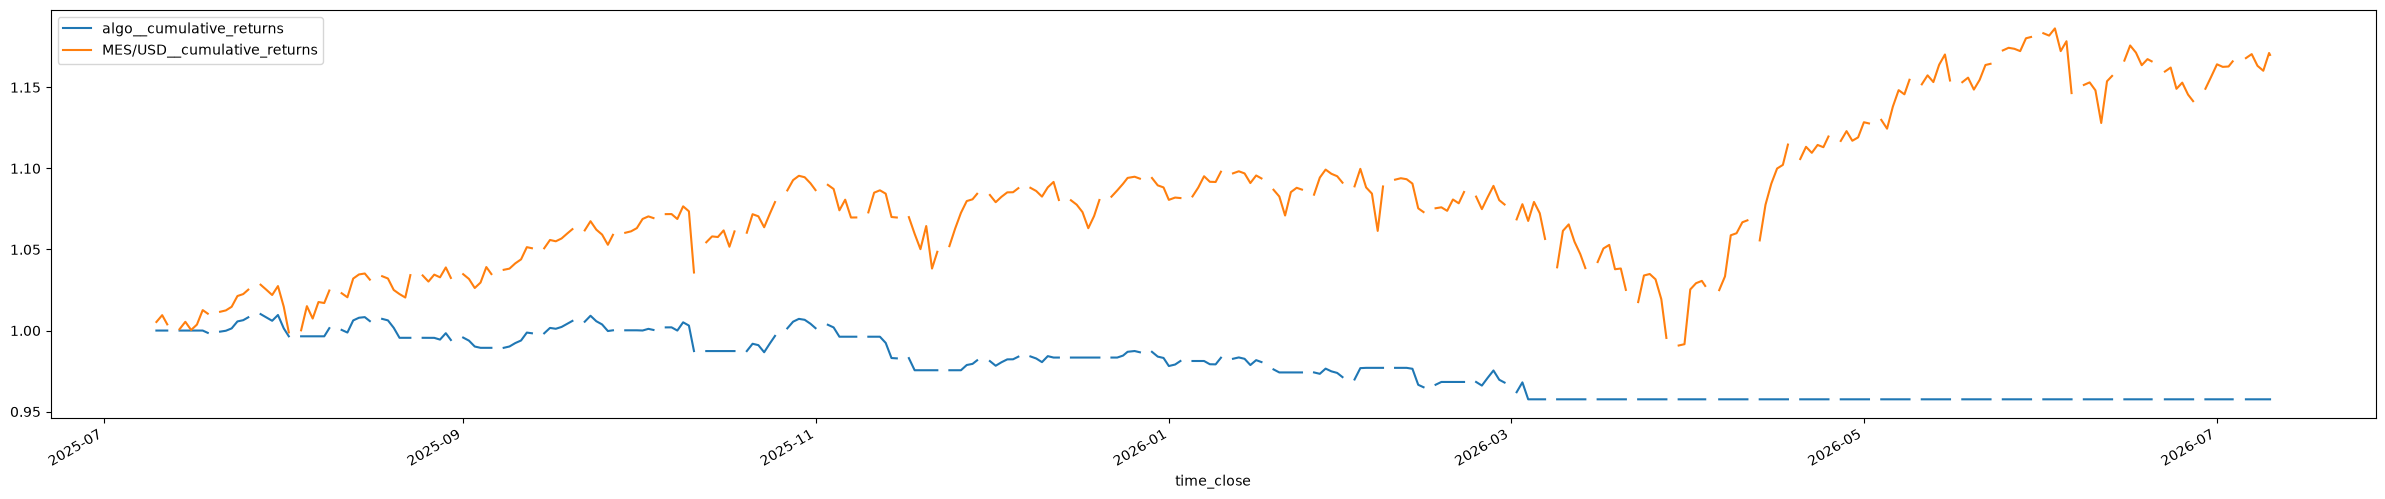

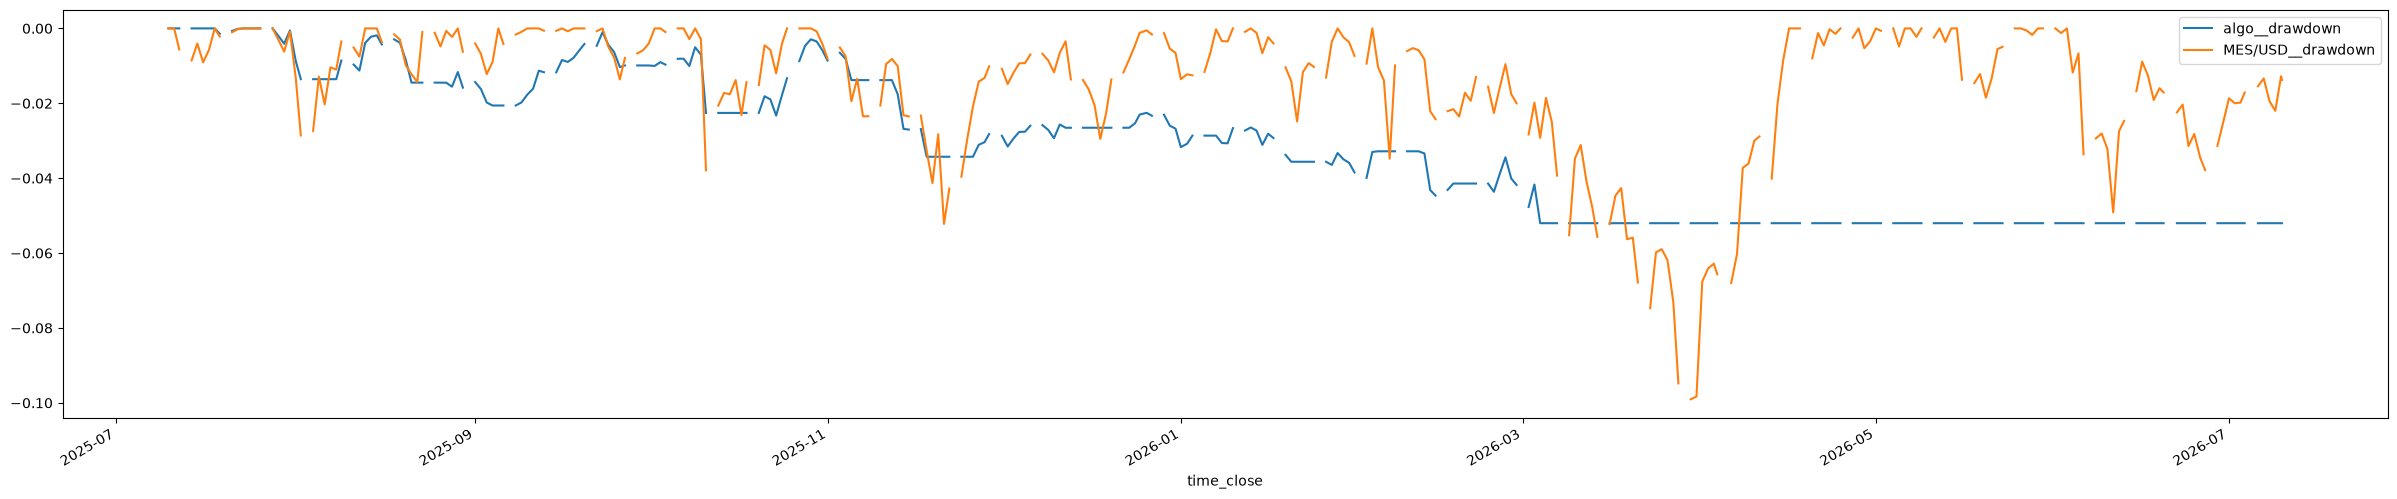

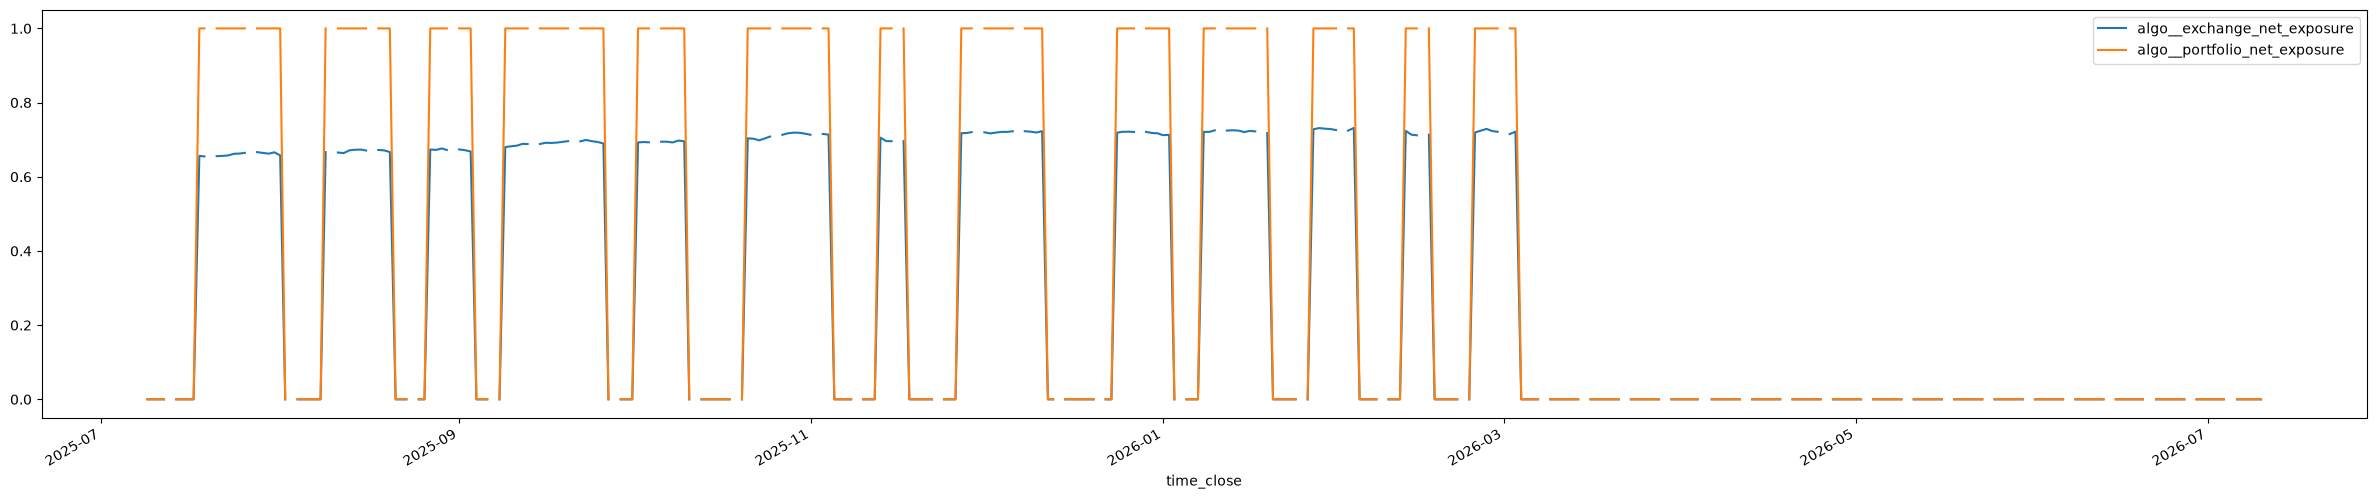

In [14]:

# run only one next step
market.reset()

# Tradeify-style EOD-trailing 5% drawdown, permanently halts trading (account_failed)
# once breached -- see middleware.py / PROP_FIRM_PLAN.md.
drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.05)

backtest = Backtester(
    market=market,
    portfolio=portfolio,
    exchange=exchange,
    reporter=reporter,
    middlewares=[drawdown_middleware],
)
# deposit prop-firm-sized funds so we can trade
backtest.exchange.transactions.add_deposit(asset="USD", volume=50000)
backtest.run_all()

# Print Report
print("Candles Processed: ", backtest.market.current['num'])
print("Account failed (drawdown breach): ", drawdown_middleware.account_failed)
print("Report", json.dumps(backtest.reporter.summary, sort_keys=True, indent=2, default=str))

if backtest.reporter.merged is not None:
    # Print a chart to compare the returns
    backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns"
        ], figsize=(30,6))

    backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown"
        ], figsize=(30,6))

    backtest.reporter.merged.plot(x="time_close", y=[
        "algo__exchange_net_exposure",
        "algo__portfolio_net_exposure"
        ], figsize=(30,6))


In [15]:
# market.merged
pd.DataFrame(backtest.exchange.get_logs())


,time,message
0,2025-07-08 14:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
1,2025-07-17 23:59:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
2,2025-08-01 08:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
3,2025-08-08 07:59:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
4,2025-08-20 14:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
5,2025-08-26 22:59:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
6,2025-09-03 05:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
7,2025-09-08 13:59:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
8,2025-09-26 14:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
9,2025-10-01 19:59:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...


In [16]:
# get dataframe with all the trades that were executed
def _trade_to_dict(trade):
    d = trade.__dict__.copy()
    for k, v in d.items():
        if hasattr(v, "value"):
            d[k] = v.value
    return d

pd.DataFrame([_trade_to_dict(t) for t in backtest.reporter.trades])


,symbol,side,time_open,time_close,open_price,close_price,close_reason,pnl,result,holding_period
0,MES/USD,long,1752796799999000000,1754038799999000000,6562.75,6527.25,signal,-0.005409,loser,1242000000000000
1,MES/USD,long,1754639999999000000,1755701999999000000,6590.75,6581.50,signal,-0.001403,loser,1062000000000000
2,MES/USD,long,1756249199999000000,1756879199999000000,6704.75,6643.00,signal,-0.009210,loser,630000000000000
3,MES/USD,long,1757339999999000000,1758898799999000000,6720.25,6828.25,signal,0.016071,winner,1558800000000000
4,MES/USD,long,1759348799999000000,1760122799999000000,6928.25,6800.25,signal,-0.018475,loser,774000000000000
5,MES/USD,long,1760965199999000000,1762239599999000000,6901.00,6989.50,signal,0.012824,winner,1274400000000000
6,MES/USD,long,1762955999999000000,1763413199999000000,7066.25,6859.50,signal,-0.029259,loser,457200000000000
7,MES/USD,long,1764122399999000000,1765457999999000000,6966.25,7044.50,signal,0.011233,winner,1335600000000000
8,MES/USD,long,1766505599999000000,1767333599999000000,7055.50,7034.25,signal,-0.003012,loser,828000000000000
9,MES/USD,long,1767815999999000000,1768798799999000000,7095.50,7025.00,signal,-0.009936,loser,982800000000000
